### Overview

Building upon the previous capstone work, which focused on data aggregation, cleaning, processing, and visualization, this phase aims to develop machine learning models to predict hourly bike rental counts. The project will cover feature engineering, scaling, and regression modeling techniques to build an effective predictive model.

---

### Project Statement

**Develop an end-to-end machine learning pipeline to forecast hourly bike rentals using various regression techniques and performance evaluation methods.**

---

### Tasks

#### **Task 1: Feature Engineering (45 mins)**

**Input dataset:** Use your preprocessed/engineered dataset from Task 1: feature engineering (original dataset [here](https://github.com/gperdrizet/FSA_devops/blob/main/data/unit3/FloridaBikeRentals.csv)).

- Analyze the provided dataset and select relevant features.
- Create new features such as:  
    - Normalized ('ratio') features  
    - Difference features  
    - Other transformed features (log, square root, etc.)  
    - Anything else interesting you can dream up  
- Encode categorical variables and handle missing values.
- Scale the numerical features using `StandardScaler`.
- Save the processed dataset as **"bike_rental_features.csv"**.

---

#### **Task 2: Model Building (75 mins)**

- Implement various regression models including:  
    - Linear Regression  
    - Ridge Regression (L2 Regularization)  
    - Lasso Regression (L1 Regularization)  
    - Elastic Net Regression  
- Perform hyperparameter tuning using `GridSearchCV`.
- Evaluate model performance using:  
    - Mean Absolute Error (MAE)  
    - Mean Squared Error (MSE)  
    - R-squared (R²)  

---

#### **Task 3: Model Building with Polynomial Features (45 mins)**

- Create polynomial features for selected numerical columns.
- Train models with polynomial features to capture non-linear relationships.
- Compare results with linear models to assess improvements.
- Save the best-performing model.

---

#### **Task 4: Model Evaluation and Validation (45 mins)**

- Perform cross-validation techniques to validate model performance (on both models - With Polynomial Features and Without Polynomial Features).
- Assess models using test data.
- Compare results across different regression models.
- Summarize findings and key takeaways from the analysis.
- Discuss feature importance and business implications.
- Provide recommendations for further improvements.


### Task 1 Feature Engineering ###
- Analyze the provided dataset and select relevant features.
- Create new features such as:  
    - Normalized ('ratio') features  
    - Difference features  
    - Other transformed features (log, square root, etc.)  
    - Anything else interesting you can dream up  
- Encode categorical variables and handle missing values.
- Scale the numerical features using `StandardScaler`.
- Save the processed dataset as **"bike_rental_features.csv"**.

In [143]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer


fbr_df = pd.read_csv('FloridaBikeRentals.csv')
# Display the first few rows of the dataset
print(fbr_df.head().to_string())

print(fbr_df.info())
print(fbr_df.describe().to_string())
# Print categorical columns' unique values
categorical_cols = fbr_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Unique values in '{col}': {fbr_df[col].unique()}")

         Date  Rented Bike Count  Hour  Temperature(C)  Humidity(%)  Wind speed (m/s)  Visibility (10m)  Dew point temperature(C)  Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday Functioning Day
0  01/12/2017                254     0            -5.2           37               2.2              2000                     -17.6                      0.0           0.0            0.0  Winter  No Holiday             Yes
1  01/12/2017                204     1            -5.5           38               0.8              2000                     -17.6                      0.0           0.0            0.0  Winter  No Holiday             Yes
2  01/12/2017                173     2            -6.0           39               1.0              2000                     -17.7                      0.0           0.0            0.0  Winter  No Holiday             Yes
3  01/12/2017                107     3            -6.2           40               0.9              2000                 

In [144]:
# rename dataframe columns to lowercase
fbr_df.columns = fbr_df.columns.str.lower()
# rename dataframe columns to replace spaces with underscores (snake case)
fbr_df.columns = fbr_df.columns.str.replace(' ', '_')
# Remove any underscore in the column name if before a paranthesis
fbr_df.columns = fbr_df.columns.str.replace('_(', '(', regex=False)
# Remove any parenthesis in the column name
fbr_df.columns = fbr_df.columns.str.replace(pat=r'\(.*\)', repl='', regex=True)

# Resize dtypes to optimize memory usage
for col in fbr_df.columns:
    if fbr_df[col].dtype == 'float64':
        fbr_df[col] = pd.to_numeric(fbr_df[col], downcast='float')
    elif fbr_df[col].dtype == 'int64':
        fbr_df[col] = pd.to_numeric(fbr_df[col], downcast='integer')
# Change date column to datetime type for day/month/year extraction
fbr_df['date'] = pd.to_datetime(fbr_df['date'], format='%d/%m/%Y')
# Change yes/no columns to use boolean type
fbr_df['holiday'] = fbr_df['holiday'].map({'Holiday': True, 'No Holiday': False}).astype('boolean')
fbr_df['functioning_day'] = fbr_df['functioning_day'].map({'Yes': True, 'No': False}).astype('boolean')
# One hot encode seasons
# This drops seasons_Autumn to avoid the dummy variable trap <- Ask about in class: copilot wrote the comment before I turned it off and I wasn't sure what it meant
fbr_df = pd.get_dummies(fbr_df, columns=['seasons'], drop_first=True)
# Break up date into multiple features
fbr_df['year'] = fbr_df['date'].dt.year.astype('int16')
fbr_df['month'] = fbr_df['date'].dt.month.astype('int8')
fbr_df['day'] = fbr_df['date'].dt.day.astype('int8')
fbr_df['day_of_week'] = fbr_df['date'].dt.dayofweek.astype('int8')
# Drop original date column
fbr_df = fbr_df.drop(columns=['date'])

# Display updated dataframe info
print(fbr_df.info())
print(fbr_df.describe().to_string())
# Save cleaned dataframe to new CSV file
fbr_df.to_csv('bike_rental_features.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rented_bike_count      8760 non-null   int16  
 1   hour                   8760 non-null   int8   
 2   temperature            8760 non-null   float32
 3   humidity               8760 non-null   int8   
 4   wind_speed             8760 non-null   float32
 5   visibility             8760 non-null   int16  
 6   dew_point_temperature  8760 non-null   float32
 7   solar_radiation        8760 non-null   float32
 8   rainfall               8760 non-null   float32
 9   snowfall               8760 non-null   float32
 10  holiday                8760 non-null   boolean
 11  functioning_day        8760 non-null   boolean
 12  seasons_Spring         8760 non-null   bool   
 13  seasons_Summer         8760 non-null   bool   
 14  seasons_Winter         8760 non-null   bool   
 15  year

In [145]:
# Scale numerical features using sklearn's standard scaler
# Leaving out day, month, and year. If this becomes an issue maybe change them later, or ask in class
# Don't scale rented_bike_count as that is the target variable
numerical_features = ['temperature',
                      'humidity',
                      'wind_speed',
                      'visibility',
                      'dew_point_temperature',
                      'solar_radiation',
                      'rainfall',
                      'snowfall',
                      'hour',
                      'day',
                      'month',
                      'year',
                      'day_of_week']

scaler = StandardScaler()
scaled_fbr_df = fbr_df.copy()
scaled_fbr_df[numerical_features] = scaler.fit_transform(fbr_df[numerical_features])

# Print scaled descriptions
print(scaled_fbr_df.head().to_string())
print(scaled_fbr_df.info())
print(scaled_fbr_df.describe().to_string())

   rented_bike_count      hour  temperature  humidity  wind_speed  visibility  dew_point_temperature  solar_radiation  rainfall  snowfall  holiday  functioning_day  seasons_Spring  seasons_Summer  seasons_Winter      year     month       day  day_of_week
0                254 -1.661325    -1.513957 -1.042483    0.458476    0.925871              -1.659605        -0.655132   -0.1318 -0.171891    False             True           False           False            True -3.282407  1.587648 -1.673503     0.499144
1                204 -1.516862    -1.539074 -0.993370   -0.892561    0.925871              -1.659605        -0.655132   -0.1318 -0.171891    False             True           False           False            True -3.282407  1.587648 -1.673503     0.499144
2                173 -1.372399    -1.580936 -0.944257   -0.699556    0.925871              -1.667262        -0.655132   -0.1318 -0.171891    False             True           False           False            True -3.282407  1.587648 -1.

### Task 2 Model Building ###
- Implement various regression models including:  
    - Linear Regression  
    - Ridge Regression (L2 Regularization)  
    - Lasso Regression (L1 Regularization)  
    - Elastic Net Regression  
- Perform hyperparameter tuning using `GridSearchCV`.
- Evaluate model performance using:  
    - Mean Absolute Error (MAE)  
    - Mean Squared Error (MSE)  
    - R-squared (R²)  

3.10.7
0.13.2


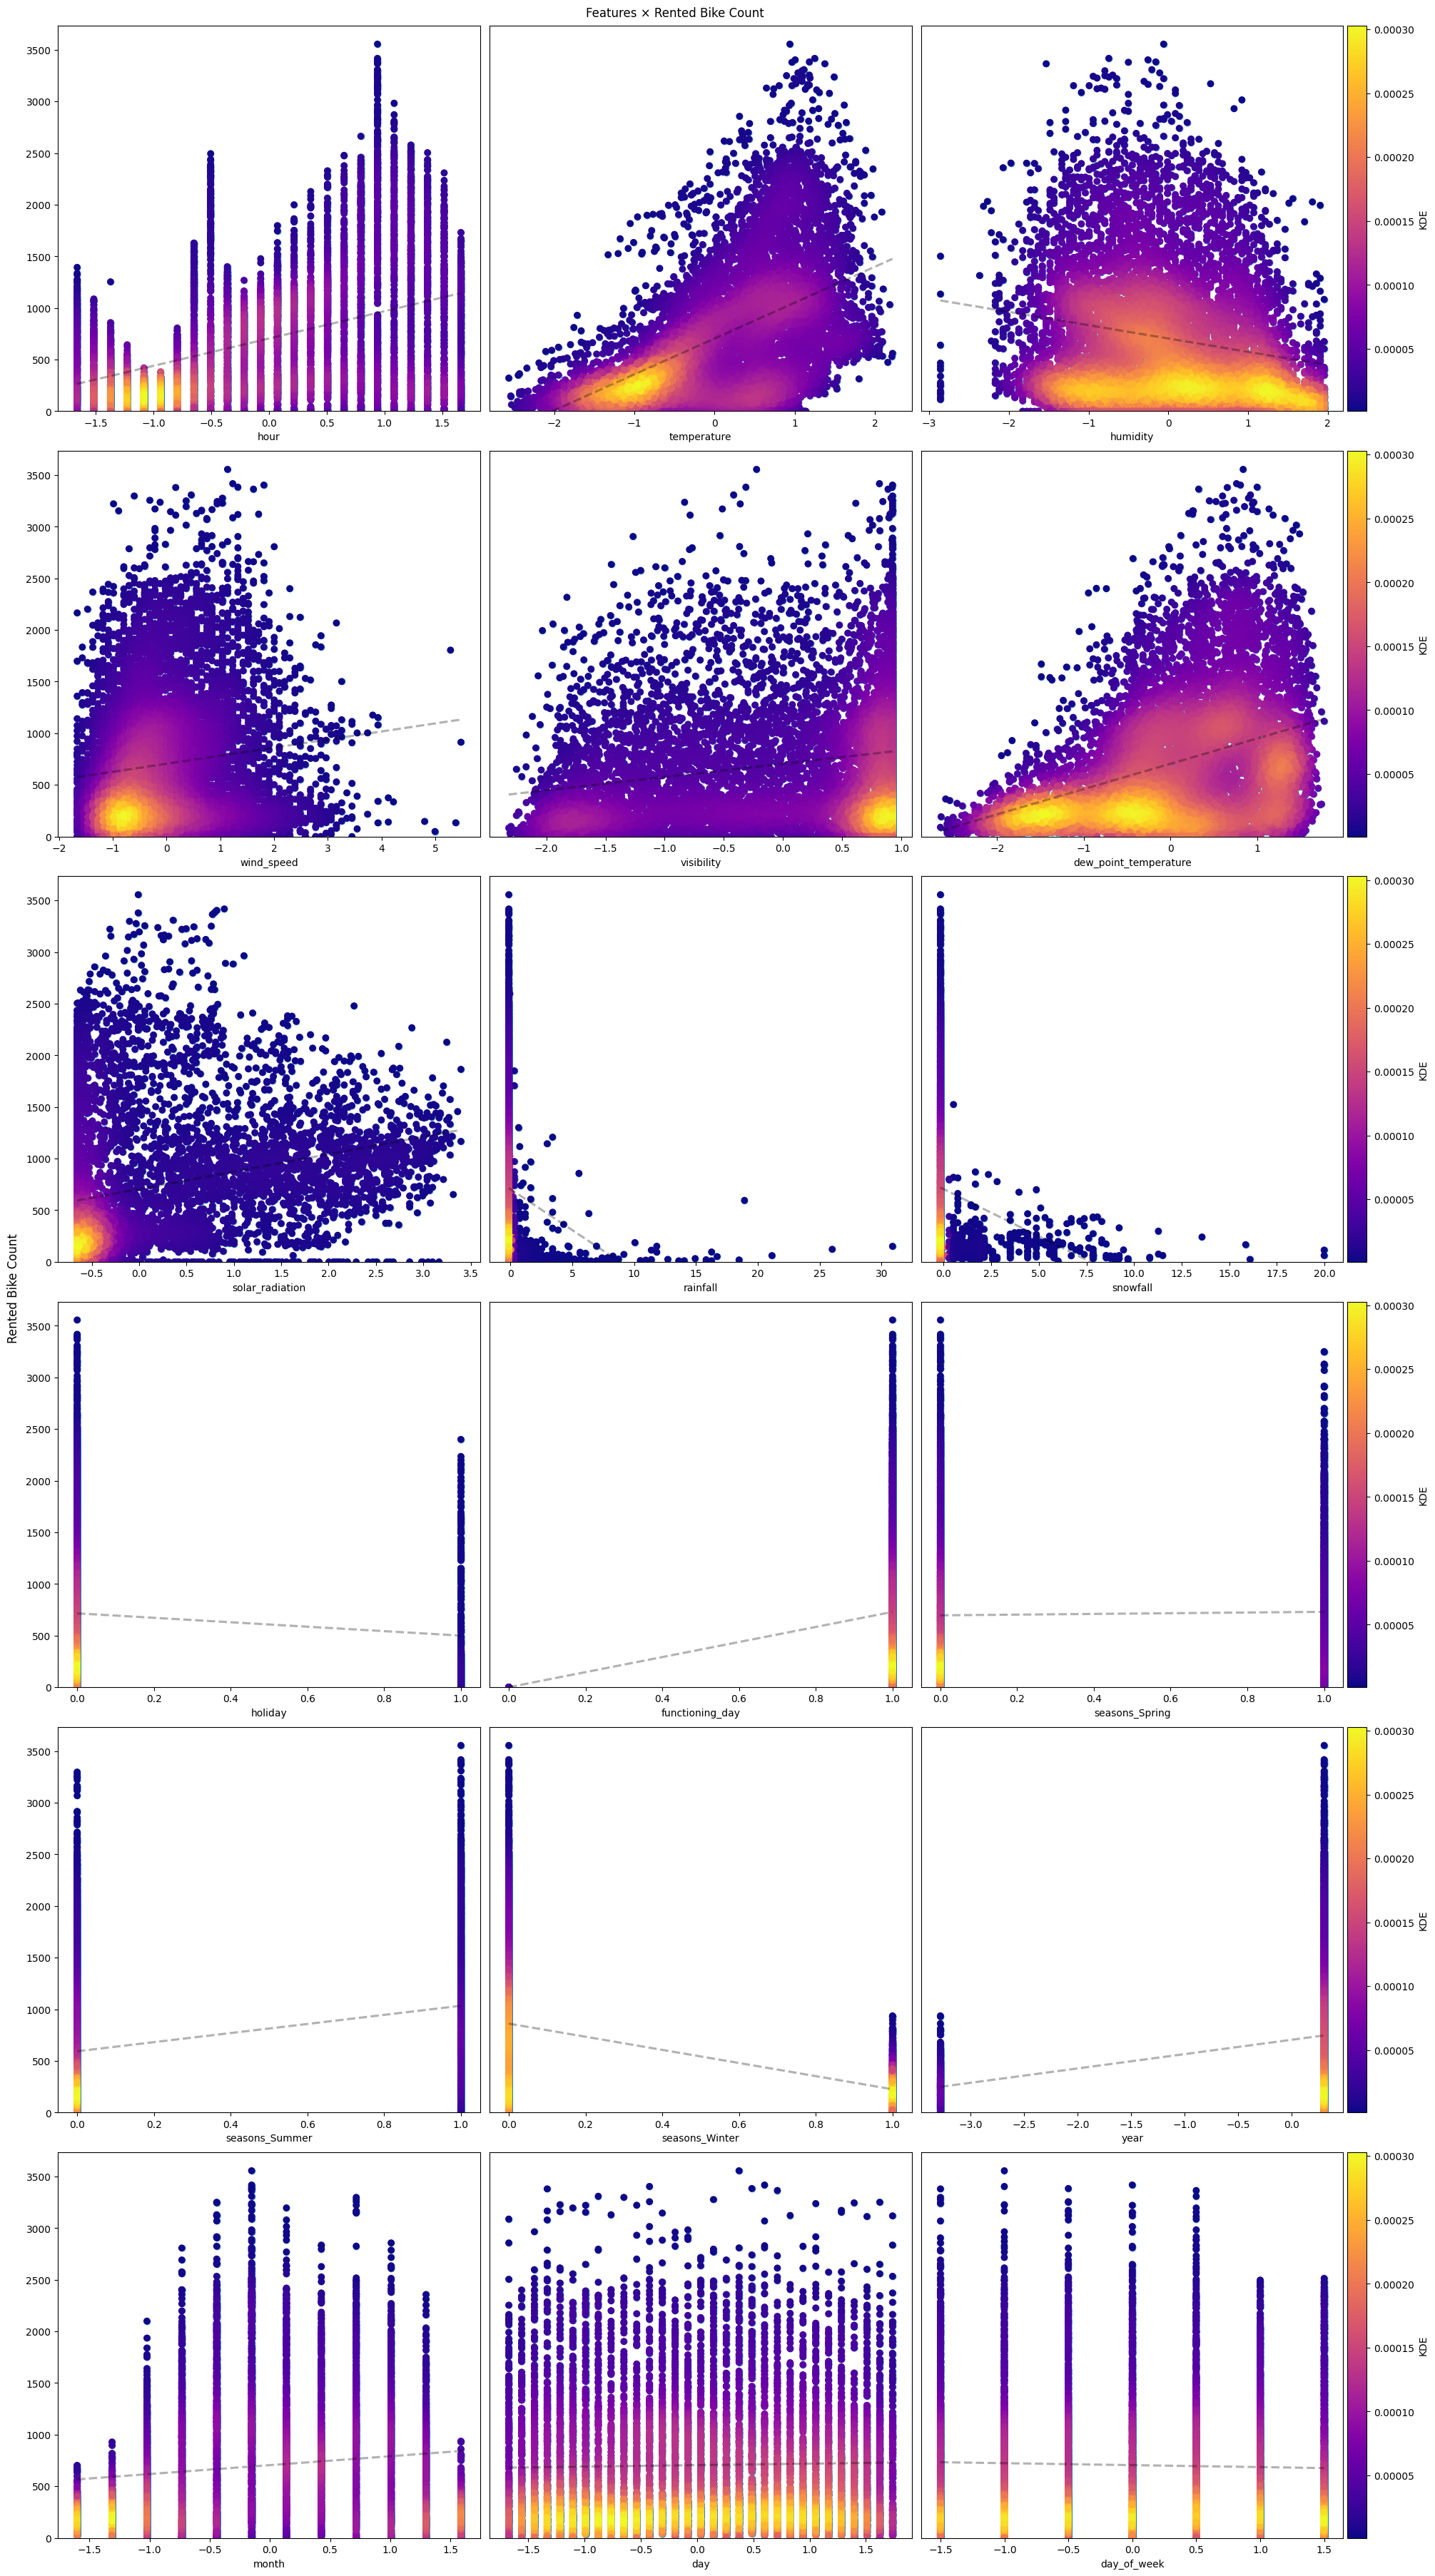

In [146]:
# plot some graphs of features modeled against rented_bike_count
from scipy.stats import gaussian_kde
from math import ceil
import matplotlib
print(matplotlib.__version__)
print(sns.__version__)
df = scaled_fbr_df.copy().drop(columns=['rented_bike_count'])
y = scaled_fbr_df['rented_bike_count']

caxy = 0
caxx = 0
height = ceil(len(df.columns)/3)
sub_fig, axs = plt.subplots(height,3, sharey=True, figsize=(20,6*height), constrained_layout=True)
counter = 0
lkws = {'color':'black', 'linestyle':'--', 'alpha':0.3}
cbax = []
for ax, col in zip(axs.flatten(), df.columns):
    df_x = df[col]
    xy = np.vstack([df_x, y])
    dens = gaussian_kde(xy)(xy)
    g = sns.regplot(x=df_x,y=y,ci=False, ax=ax, line_kws=lkws, label='Trend Line')
    g.set(ylim=(0,None))
    plot_scat = ax.scatter(df_x, y, c=dens, cmap='plasma')
    ax.set_xlabel(col)
    ax.set_ylabel('')
    if counter and counter % 3 != 0:
        ax.tick_params(axis='y', which='both', left=False, right=False)
    if counter and (counter+1) % 3 == 0:
        cbax.append(ax)
    counter += 1
    
sub_fig.suptitle('Features × Rented Bike Count', x=0.47, ha='center')
sub_fig.supylabel('Rented Bike Count')
# axs[1].legend(loc='upper left')
for ax in cbax:
    plt.colorbar(plot_scat, ax=ax, pad=0.01, label='KDE')
plt.show()

In [ ]:
%pip install hyperopt -q
%pip install hyperopt-sklearn -q
# Test out hyperopt for hyperparameter tuning
from hpsklearn import HyperoptEstimator, any_classifier, any_regressor, any_sparse_regressor, any_preprocessing, all_classifiers, all_regressors, all_preprocessing
import hpsklearn as hpskl
from hyperopt import tpe
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
knn_model = KNeighborsRegressor(algorithm='kd_tree', leaf_size=23, n_jobs=1, n_neighbors=4,
                    weights='distance')
pre = PolynomialFeatures(order='F', degree=2)
pca = PCA(n_components=72)

pred = pre.fit_transform(scaled_fbr_df.drop(columns=['rented_bike_count']))
pca_pred = pca.fit_transform(pred)

lin_model = LinearRegression()
rid_model = Ridge(alpha=1.0, )
las_model = Lasso(alpha=0.3, max_iter=20000)
ela_model = ElasticNet(alpha=0.3, l1_ratio=0.5)
dtr_model = DecisionTreeRegressor(max_depth=5, random_state=691)
# Array of models for ease of looping
models = [lin_model, rid_model, las_model, ela_model, dtr_model, knn_model]
param_grids = [{},
               {'alpha':range(1.0,5.0,0.5),'positive':[True], 'solver':['svd','lbfgs']},
               {'alpha':range(0.3,1.0,0.1), 'max_iter':range(5000,30000,5000)},
               {'alpha':range(0.3,1.0,0.1), 'l1_ratio':range(0.1,0.5,0.1)},
               {'max_depth':range(4,22,1), 'max_features':range(4,20,1)},
               {'algorithm':['kd_tree','ball_tree'], 'leaf_size':range(5,25,1), 'n_jobs':[1], 'n_neighbors':range(2,8,1), 'weights':['distance','uniform']},
               ]

# Break up data into testing and training data
X = pca_pred
y = scaled_fbr_df['rented_bike_count']

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=.20, random_state=1738)
# print(train_X.info())
# print(test_X.info())
# print(train_X.describe().to_string())
# print(test_X.describe().to_string())
# print(train_y.array)
# Fit all models and print their coefficients if applicable
print(f"mean of rented bikes: {y.mean()}")
for model, p_grid in zip(models, param_grids):
    grid_search = GridSearchCV(
    model,
    # param_grid={ 'alpha':[0.1,0.5] },
    param_grid=p_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=16
    )

    # Fit on training data
    grid_search.fit(
        train_X,
        train_y
    )
    print(type(grid_search.best_params_))
    print(grid_search.best_params_)
    
    if len(grid_search.best_params_):
        for k, v in grid_search.best_params_.items():
            # k, v = p
            print(f'Best {k}: {v}')
        print(f'Best CV RMSE: {-grid_search.best_score_:.1f}')
    
    model.fit(train_X, train_y)
    print(f"\nModel: {model.__class__.__name__}")
    # if hasattr(model, 'coef_'):
    #     print("Coefficients:", model.coef_)
    if hasattr(model, 'intercept_'):
        print("Intercept:", model.intercept_)
    
    # Get predictions from both training and testing
    y_train_pred = model.predict(train_X)
    y_test_pred = model.predict(test_X)
    
    # Get RMSEs out of both dt predictions
    train_rmse = root_mean_squared_error(train_y, y_train_pred)
    test_rmse = root_mean_squared_error(test_y, y_test_pred)

    # Print metrics
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Testing RMSE:  {test_rmse:.4f}")

# estim = HyperoptEstimator(regressor=any_sparse_regressor("my_reg"),
#                           preprocessing=[hpskl.polynomial_features("my_pol",2),
#                                         #  hpskl.min_max_scaler("my_mm"),
#                                         #  hpskl.quantile_transformer("my_qy"),
#                                         #  hpskl.k_bins_discretizer("my_kbin"),
#                                          hpskl.pca("my_pca")],
#                           algo=tpe.suggest,
#                           max_evals=200,
#                           trial_timeout=20)
    
# estim.fit(train_X, train_y)

# print(estim.score(test_X, test_y))

# print(estim.best_model())


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
mean of rented bikes: 704.6020547945205


/usr/lib64/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib64/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib64/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


<class 'dict'>
{}

Model: LinearRegression
Intercept: 704.809089743218
Training RMSE: 401.8564
Testing RMSE:  403.1330


/usr/lib64/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib64/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib64/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/li

<class 'dict'>
{'alpha': 5.0, 'positive': True, 'solver': 'lbfgs'}
Best alpha: 5.0
Best positive: True
Best solver: lbfgs
Best CV RMSE: 559.0

Model: Ridge
Intercept: 704.8089104264888
Training RMSE: 401.8564
Testing RMSE:  403.1321


/usr/lib64/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


<class 'dict'>
{'alpha': 1.0, 'max_iter': 5000}
Best alpha: 1.0
Best max_iter: 5000
Best CV RMSE: 412.6

Model: Lasso
Intercept: 704.8292599109158
Training RMSE: 401.8675
Testing RMSE:  403.0758
<class 'dict'>
{'alpha': 0.3, 'l1_ratio': 0.5}
Best alpha: 0.3
Best l1_ratio: 0.5
Best CV RMSE: 410.2

Model: ElasticNet
Intercept: 704.7002239997526
Training RMSE: 404.4877
Testing RMSE:  405.3333


ValueError: Invalid parameter 'l1_ratio' for estimator DecisionTreeRegressor(max_depth=5, random_state=691). Valid parameters are: ['ccp_alpha', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'random_state', 'splitter'].

In [ ]:


for model in models:
    model.fit(train_X, train_y)
    
    # Get predictions from both training and testing
    y_train_pred = model.predict(train_X)
    y_test_pred = model.predict(test_X)
